# Financial Fraud Detection - Exploratory Data Analysis 

Here I am performing a exploratory data anlysis on a synthetic dataset of bank transactions provided by the cybersecurity team at Caishen, a NYC-based international bank. The goal is to understand the structure of the data and identify patterns that distinguish fraudulent transactions from legitimate ones. 

I will be performing univariate, bivariate, and multivariate analysis to formulate a hypothesis before moving into data cleaning and modeling. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Loading the Dataset
The dataset contains simulated bank transactions with information about the sender, receiver, transaction type, and whether the transaction was fraudulent.

In [3]:
#Loading the dataset
df = pd.read_csv('data/Financial_dataset.csv')

#Quick overview
print(f'Dataset shape: {df.shape}')
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Dataset shape: (6362620, 11)
Number of rows: 6362620
Number of columns: 11


In [34]:
print('Columns for the Dataset:', list(df.columns))

Columns for the Dataset: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [19]:
#Checking data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [31]:
print('First 10 Rows')
df.head(10)

First 10 Rows


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [32]:
print('Last 10 Rows')
df.tail(10)

Last 10 Rows


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362610,742,TRANSFER,63416.99,C778071008,63416.99,0.0,C1812552860,0.00,0.00,1,0
6362611,742,CASH_OUT,63416.99,C994950684,63416.99,0.0,C1662241365,276433.18,339850.17,1,0
6362612,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.0,C1470998563,0.00,0.00,1,0
6362613,743,CASH_OUT,1258818.82,C1436118706,1258818.82,0.0,C1240760502,503464.50,1762283.33,1,0
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.0,C1850423904,0.00,0.00,1,0
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [29]:
#Checking for any missing values 
print('Displaying any missing values')
df.isnull().sum()

Displaying any missing values


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [30]:
#Checking for duplicated rows 
print('Checking for duplicates:', df.duplicated().sum())

Checking for duplicates: 0


In [35]:
print('These are the data types for the dataset columns')
df.dtypes

These are the data types for the dataset columns


step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [36]:
print('Fraud Data')
df.describe()

Fraud Data


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


---
# Univariate Analysis

I will start by looking at each variable individually to understand distributions and spot anything unusual.

First I want to find out what is the distribution of the target variable isFraud.

Fraud Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.13%


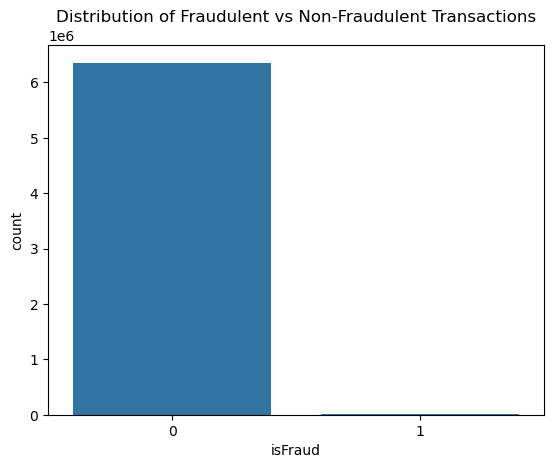

In [4]:
print('Fraud Distribution:')
print(df['isFraud'].value_counts())
print(f'\nFraud rate: {df["isFraud"].mean()*100:.2f}%')

sns.countplot(x='isFraud', data=df)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.savefig('images/fraud_distribution.png', bbox_inches='tight')
plt.show()

The dataset is heavily imbalanced. Fraud makes up a very small percentage of total transactions. A model that just predicts not fraud for everything would have high accuracy but would miss every single fraud case.

# Transaction Type Distribution

Transaction Type Counts:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


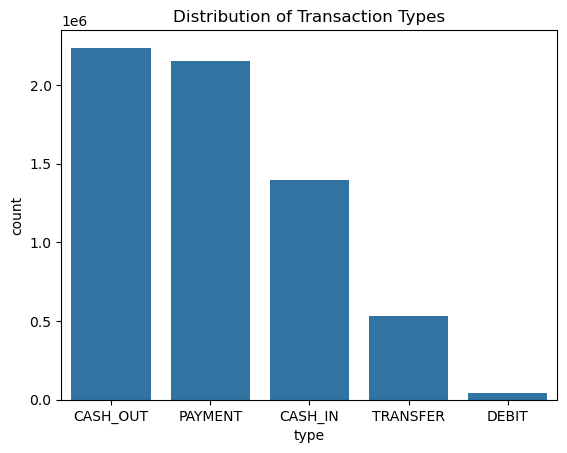

In [5]:
print('Transaction Type Counts:')
print(df['type'].value_counts())

sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title('Distribution of Transaction Types')
plt.savefig('images/transaction_types.png', bbox_inches='tight')
plt.show()

# Transaction Amount Distribution

Amount Statistics:
count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64


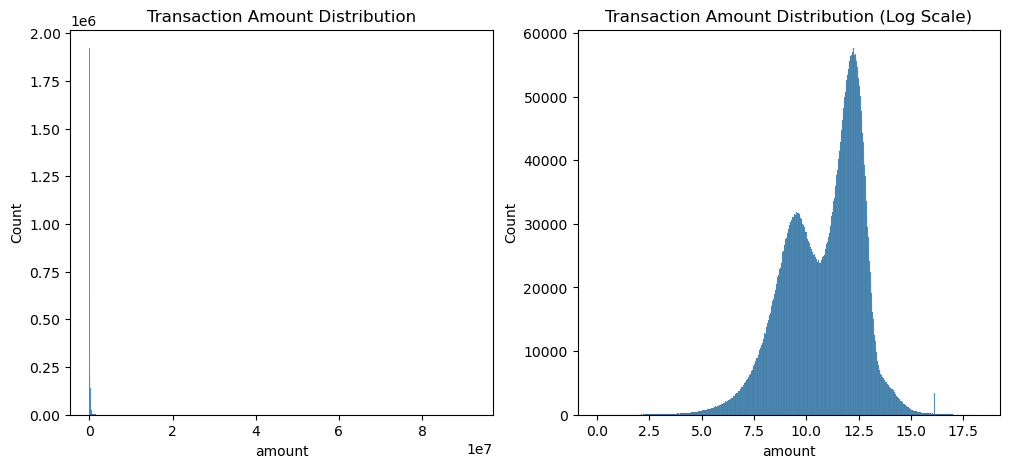

In [6]:
# Transaction amount distribution 
print('Amount Statistics:')
print(df['amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df, x='amount', ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
sns.histplot(data=df, x=np.log1p(df['amount']), ax=axes[1])
axes[1].set_title('Transaction Amount Distribution (Log Scale)')
plt.savefig('images/amount_distribution.png', bbox_inches='tight')
plt.show()

What does the step (time) distribution look like?

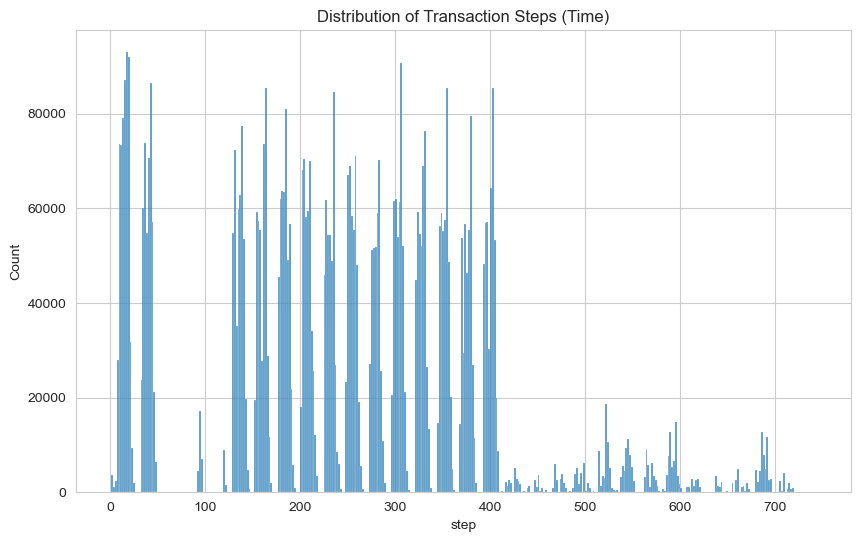

In [40]:
sns.histplot(data=df, x='step')
plt.title('Distribution of Transaction Steps (Time)')
plt.show()

How effective is the existing isFlaggedFraud system?

In [41]:
print('isFlaggedFraud Distribution:')
print(df['isFlaggedFraud'].value_counts())
print(f'\nTotal flagged: {df["isFlaggedFraud"].sum()}')
print(f'Total actual fraud: {df["isFraud"].sum()}')

isFlaggedFraud Distribution:
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

Total flagged: 16
Total actual fraud: 8213


--- 
# Bivariate Analysis 
Now I want to look at the relationships between features and the target variable.

Which transaction types have fraud?

Fraud count by type:
type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


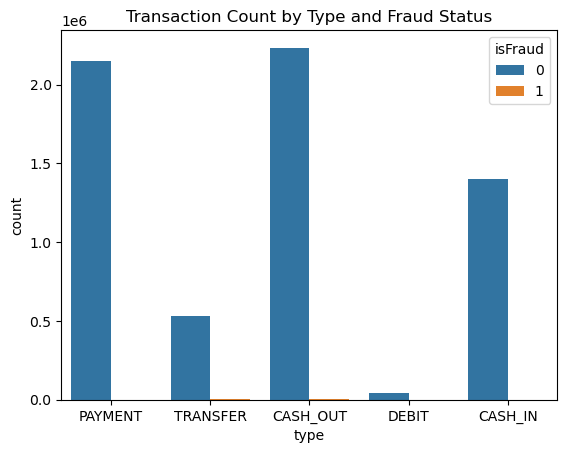

In [7]:
print('Fraud count by type:')
print(df.groupby('type')['isFraud'].sum())

sns.countplot(x='type', hue='isFraud', data=df)
plt.title('Transaction Count by Type and Fraud Status')
plt.savefig('images/fraud_by_type.png', bbox_inches='tight')
plt.show()

How do transaction amounts compare between fraud and non-fraud?

Amount Statistics - Non-Fraud:
count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64

Amount Statistics - Fraud:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


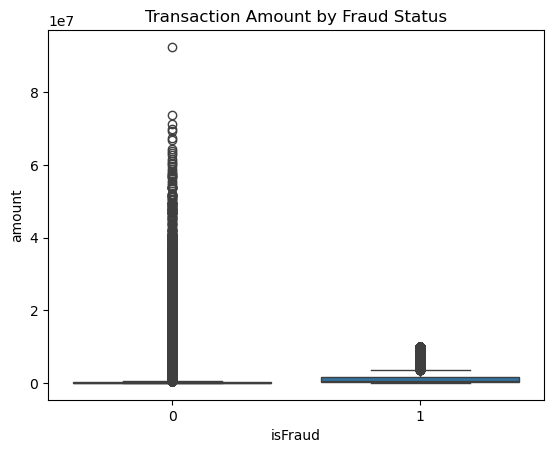

In [8]:
print('Amount Statistics - Non-Fraud:')
print(df[df['isFraud'] == 0]['amount'].describe())
print('\nAmount Statistics - Fraud:')
print(df[df['isFraud'] == 1]['amount'].describe())

sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Transaction Amount by Fraud Status')
plt.savefig('images/amount_by_fraud.png', bbox_inches='tight')
plt.show()

Do fraudulent transactions drain the origin account balance?

In [44]:
fraud_df = df[df['isFraud'] == 1]
drained = (fraud_df['newbalanceOrig'] == 0).sum()
print(f'Fraud transactions where origin balance went to 0: {drained} out of {len(fraud_df)}')
print(f'Percentage: {drained / len(fraud_df) * 100:.1f}%')

Fraud transactions where origin balance went to 0: 8053 out of 8213
Percentage: 98.1%


How do origin balances look before and after the transaction for fraud vs non-fraud?

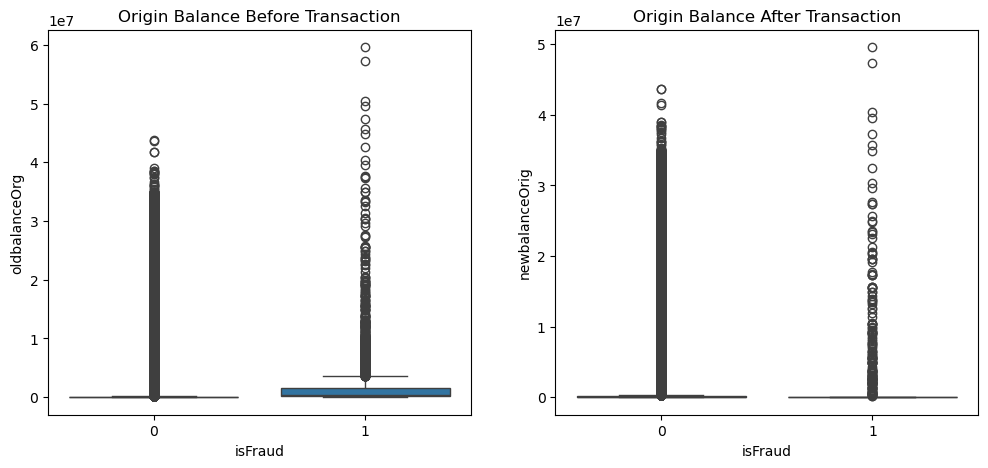

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='isFraud', y='oldbalanceOrg', data=df, ax=axes[0])
axes[0].set_title('Origin Balance Before Transaction')
sns.boxplot(x='isFraud', y='newbalanceOrig', data=df, ax=axes[1])
axes[1].set_title('Origin Balance After Transaction')
plt.savefig('images/balance_by_fraud.png', bbox_inches='tight')
plt.show()

Is there a statistically significant difference in transaction amounts between fraud and non-fraud?

In [46]:
# Mann-Whitney U test since the data is not normally distributed
fraud_amounts = df[df['isFraud'] == 1]['amount']
non_fraud_amounts = df[df['isFraud'] == 0]['amount']

stat, p_value = stats.mannwhitneyu(fraud_amounts, non_fraud_amounts, alternative='two-sided')
print(f'Mann-Whitney U statistic: {stat:.2f}')
print(f'P-value: {p_value:.6f}')

if p_value < 0.05:
    print('Statistically significant difference in amounts between fraud and non-fraud (p < 0.05)')
else:
    print('No statistically significant difference found (p >= 0.05)')

Mann-Whitney U statistic: 41224999611.00
P-value: 0.000000
Statistically significant difference in amounts between fraud and non-fraud (p < 0.05)


--- 
# Multivariate Analysis

Now I want to look at how multiple features interact together.

What does the correlation heatmap look like?

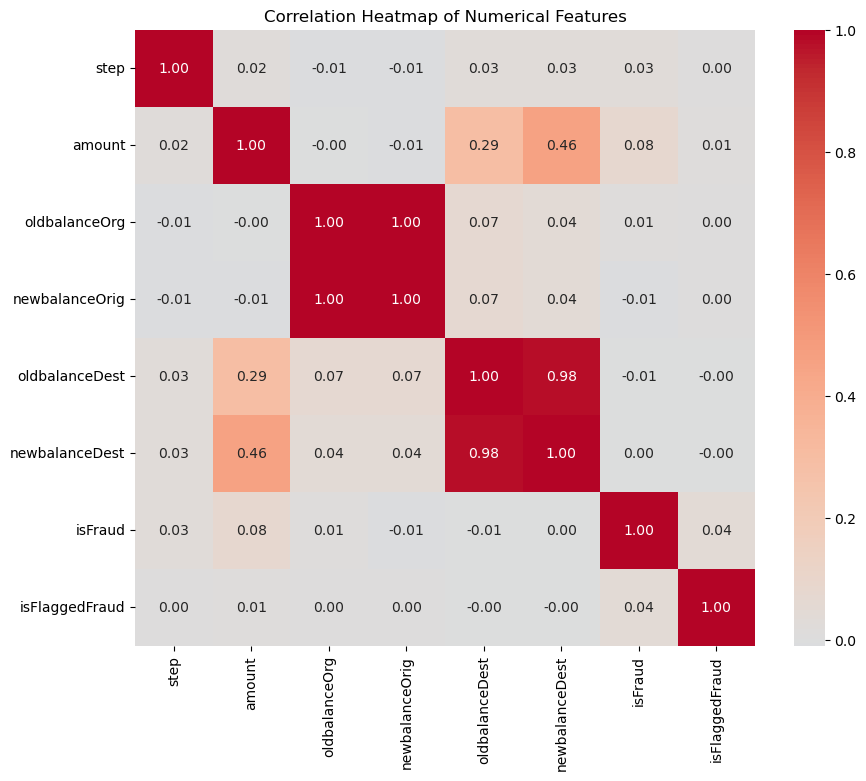

In [10]:
numerical_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                  'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

How does amount relate to origin balance for the fraud-prone transaction types?

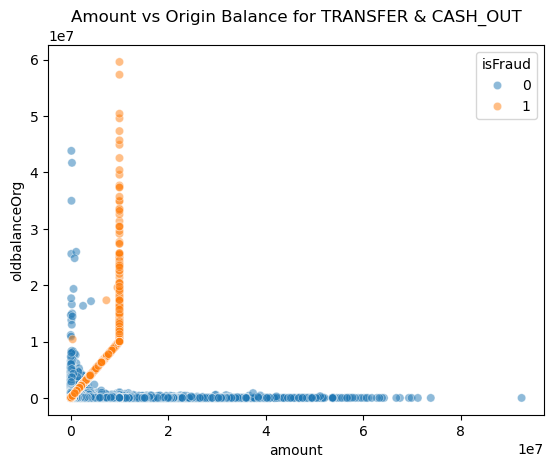

In [11]:
fraud_types = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

sns.scatterplot(x='amount', y='oldbalanceOrg', hue='isFraud',
                data=fraud_types, alpha=0.5)
plt.title('Amount vs Origin Balance for TRANSFER & CASH_OUT')
plt.savefig('images/amount_vs_balance.png', bbox_inches='tight')
plt.show()

Is there a statistically significant relationship between transaction type and fraud?

In [49]:
contingency_table = pd.crosstab(df['type'], df['isFraud'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f'Chi-Square Statistic: {chi2:.2f}')
print(f'P-value: {p_value:.6f}')
print(f'\nContingency Table:')
print(contingency_table)

if p_value < 0.05:
    print('\nStatistically significant relationship between transaction type and fraud (p < 0.05)')
else:
    print('\nNo significant relationship found (p >= 0.05)')

Chi-Square Statistic: 22082.54
P-value: 0.000000

Contingency Table:
isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097

Statistically significant relationship between transaction type and fraud (p < 0.05)


What do the pairwise relationships look like between key features?

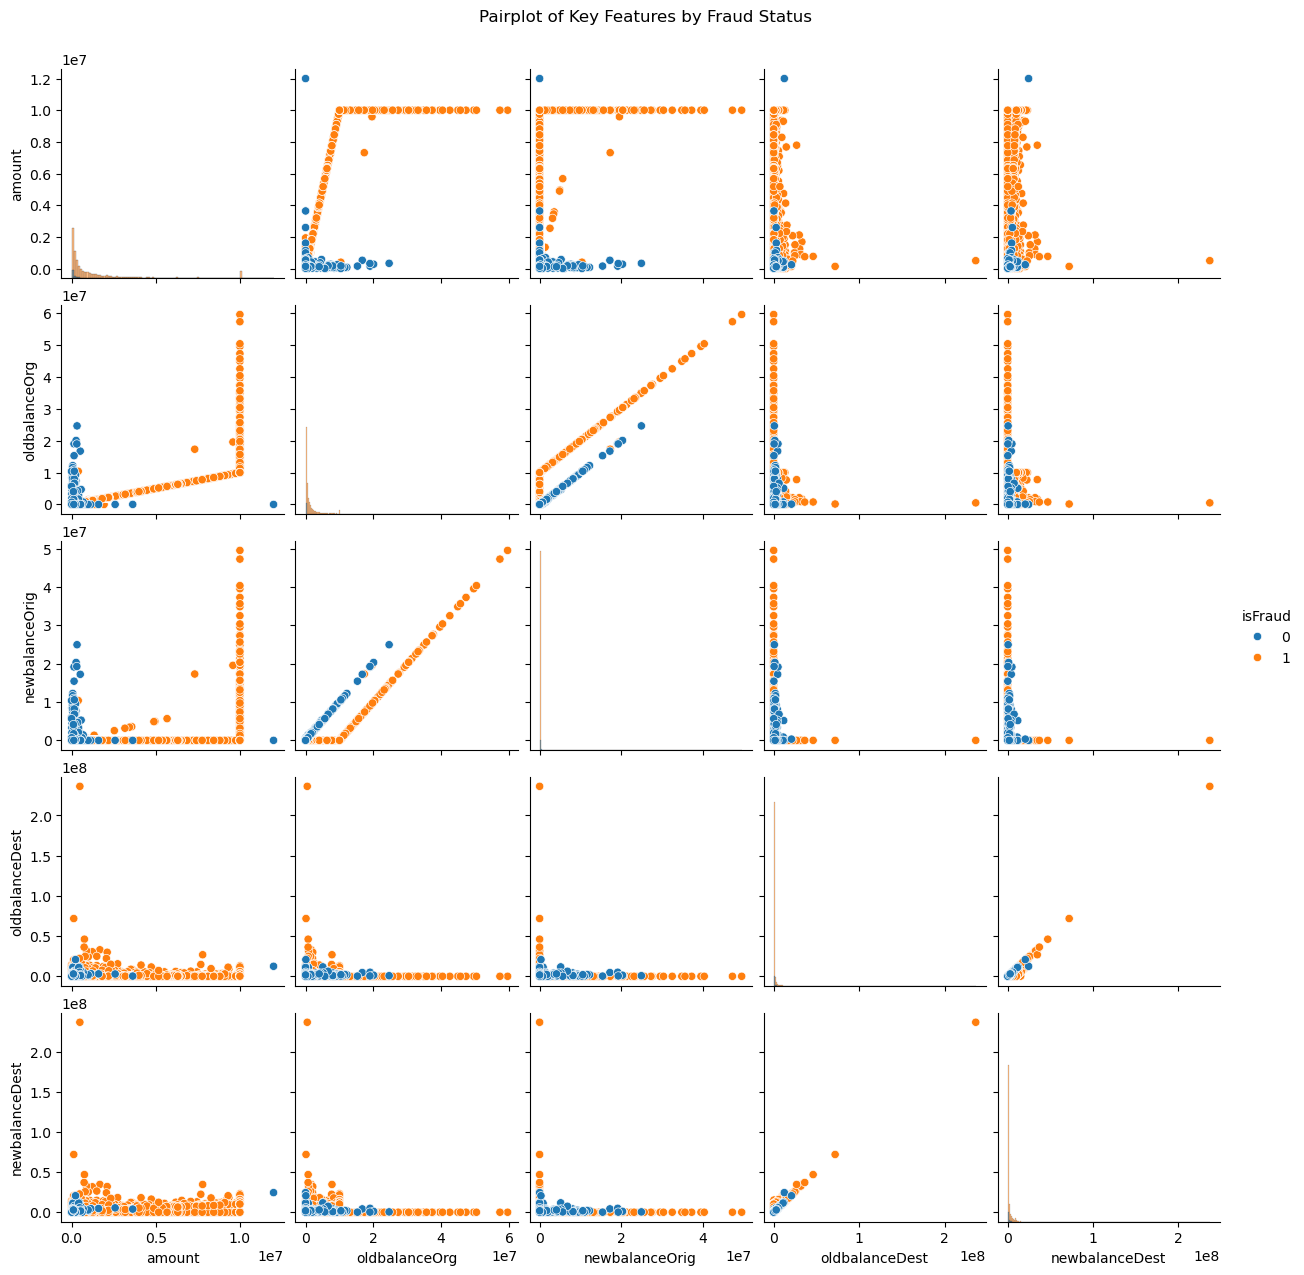

In [12]:
# Using a sample for visibility since fraud is rare
fraud_sample = df[df['isFraud'] == 1]
non_fraud_sample = df[df['isFraud'] == 0].sample(n=500, random_state=42)
plot_sample = pd.concat([fraud_sample, non_fraud_sample])

cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
sns.pairplot(plot_sample[cols], hue='isFraud', diag_kind='hist')
plt.suptitle('Pairplot of Key Features by Fraud Status', y=1.02)
plt.savefig('images/pairplot.png', bbox_inches='tight')
plt.show()